# Task 0: Course project dataset exploration (2p)

### a) Find a potential dataset for the course project, provide the name and a link to the source. (0.5p)
#### Dataset name: Customer Purchase Behavior Analysis
#### Link: https://www.kaggle.com/datasets/arfeenkabir/customer-purchase-behavior-analysis/data

### b) Briefly describe the dataset in a markdown cell and what you plan to do with it in the project. (0.5p)
#### The dataset contains 3900 rows and 19 columns with information about customer shopping behavior and trends, including variables such as customer age, gender, purchase amount, product category, purchase frequency,... 
#### In the project, I am planning to analyze what factors influence purchase amount and frequency, identify customer segments, and visualize purchasing patterns across different demographics and product categories.

### c) Conduct exploratory data analysis on the dataset (or on a sample of the data you plan to collect). This includes computing summary statistics (e.g. using .describe()) and creating at least 2 visualizations of the data. (1p)

Dataset shape: 3900 rows, 19 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


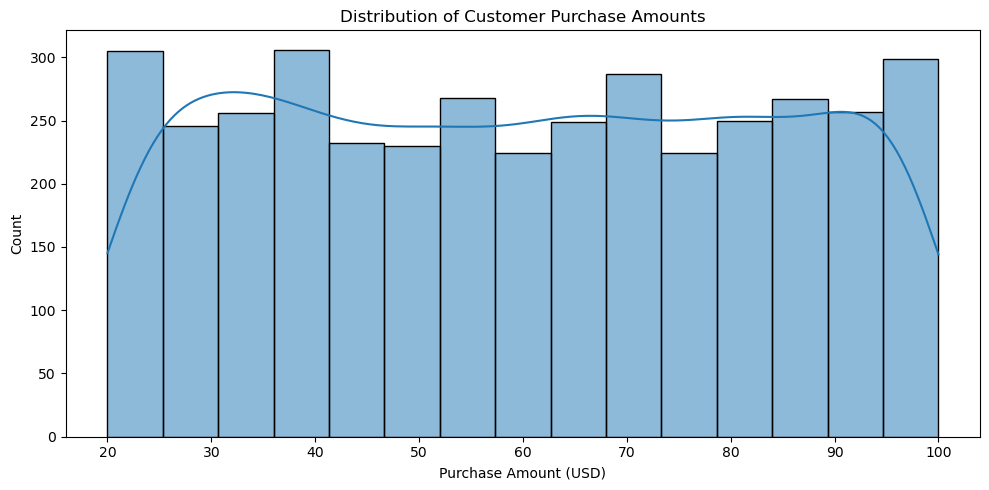

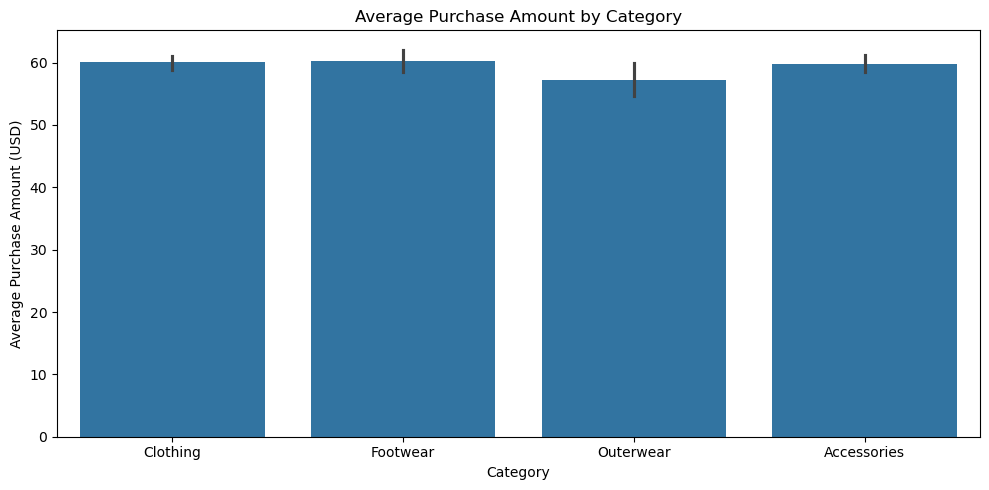

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_customers = pd.read_csv("shopping_trends.csv")

# Summary statistics
print(f"Dataset shape: {df_customers.shape[0]} rows, {df_customers.shape[1]} columns")
display(df_customers.head())
display(df_customers.describe())

# Visualization 1: Distribution of purchase amounts
plt.figure(figsize=(10, 5))
sns.histplot(data=df_customers, x="Purchase Amount (USD)", kde=True)
plt.title("Distribution of Customer Purchase Amounts")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Visualization 2: Average purchase amount by category
plt.figure(figsize=(10, 5))
sns.barplot(data=df_customers, x="Category", y="Purchase Amount (USD)")
plt.title("Average Purchase Amount by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase Amount (USD)")
plt.tight_layout()
plt.show()

# Task 1: Setting up an API key and .env file (1p)

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)
api_key = os.getenv("MY_KEY")
print(api_key[:5] + "...")

e32bb...


# Task 2: Retrieving data from MarketStack (1p)

### a) Retrieve End-of-Day (eod) data for these five stocks for March 2026.

In [3]:
import requests
import pandas as pd

tickers = "META,AAPL,AMZN,NFLX,GOOG"
url = "http://api.marketstack.com/v1/eod"
params = {
    "access_key": api_key,
    "symbols": tickers,
    "date_from": "2026-03-01",
    "date_to": "2026-03-31",
    "limit": 1000 
}

response = requests.get(url, params=params)
data = response.json()

### b) Convert the retrieved JSON data into a pandas DataFrame. Print the first 5 rows.

In [4]:
# Convert to DataFrame
df = pd.DataFrame(data["data"])

# Clean up the date column
df["date"] = pd.to_datetime(df["date"]).dt.date

display(df.head())

,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31


### c) Compute summary statistics for the closing prices grouped by stock. Also calculate the return percentage for each stock over the month (i.e. the percentage change from the first to the last trading day). Print out the computed numbers or a DataFrame that contains the numbers, and report which stock performed best and which worst in March 2026.

In [5]:
# Summary statistics of closing prices grouped by stock
summary = df.groupby("symbol")["close"].describe()
print("Summary statistics:")
display(summary)

# Return percentage
df_sorted = df.sort_values(["symbol", "date"])

returns = {}
for symbol in df["symbol"].unique():
    stock_df = df[df["symbol"] == symbol]
    first_price = stock_df.iloc[0]["close"]
    last_price = stock_df.iloc[-1]["close"]
    returns[symbol] = ((last_price - first_price) / first_price) * 100

returns_df = pd.DataFrame(list(returns.items()), columns=["symbol", "return_%"])

print("Monthly returns:")
display(returns_df)

# Best and worst performers
best_stock = returns_df.loc[returns_df["return_%"].idxmax()]
worst_stock = returns_df.loc[returns_df["return_%"].idxmin()]

print(f"Best performing stock: {best_stock['symbol']} ({best_stock['return_%']:.2f}%)")
print(f"Worst performing stock: {worst_stock['symbol']} ({worst_stock['return_%']:.2f}%)")

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
symbol,,,,,,,,
AAPL,22.0,254.906364,5.510351,246.63,250.4625,253.340,260.1875,264.72
AMZN,22.0,209.995000,4.643217,199.34,207.8200,209.700,213.0700,218.94
GOOG,22.0,297.980455,10.928636,273.14,291.7675,302.335,305.9400,309.41
META,22.0,614.990909,41.309579,525.72,593.9675,619.170,652.0175,667.73
NFLX,22.0,95.076364,2.512109,90.92,93.3350,94.795,97.0525,99.17


Monthly returns:


,symbol,return_%
0,AAPL,4.306710
1,AMZN,0.057618
2,GOOG,6.797741
3,META,14.232779
4,NFLX,0.977639


Best performing stock: META (14.23%)
Worst performing stock: AMZN (0.06%)


# Task 3: Visualizing stock data (1p)

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

### a) A line chart showing the closing price of each stock over time during March 2026.

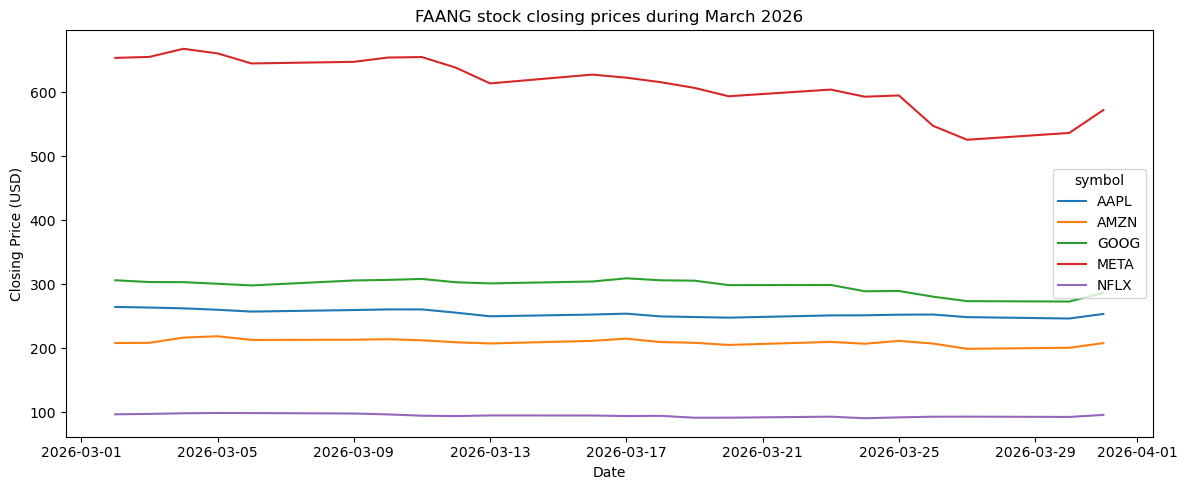

In [7]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x="date", y="close", hue="symbol")
plt.title("FAANG stock closing prices during March 2026")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.tight_layout()
plt.show()

### b) A bar plot showing the overall return percentage for each stock in March 2026.

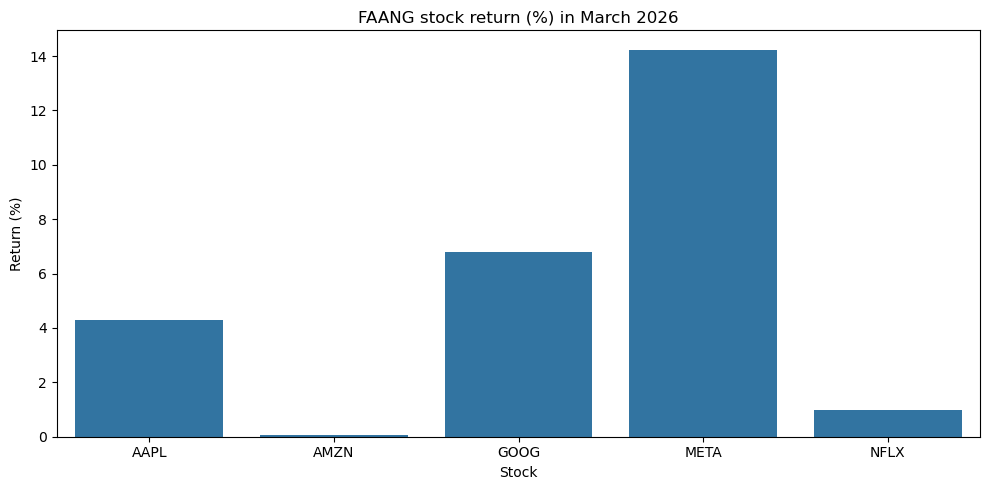

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=returns_df, x="symbol", y="return_%")
plt.title("FAANG stock return (%) in March 2026")
plt.xlabel("Stock")
plt.ylabel("Return (%)")
plt.tight_layout()
plt.show()

### c) A heatmap showing the daily trading volume for each stock (stocks on the y axis, dates on the x axis).

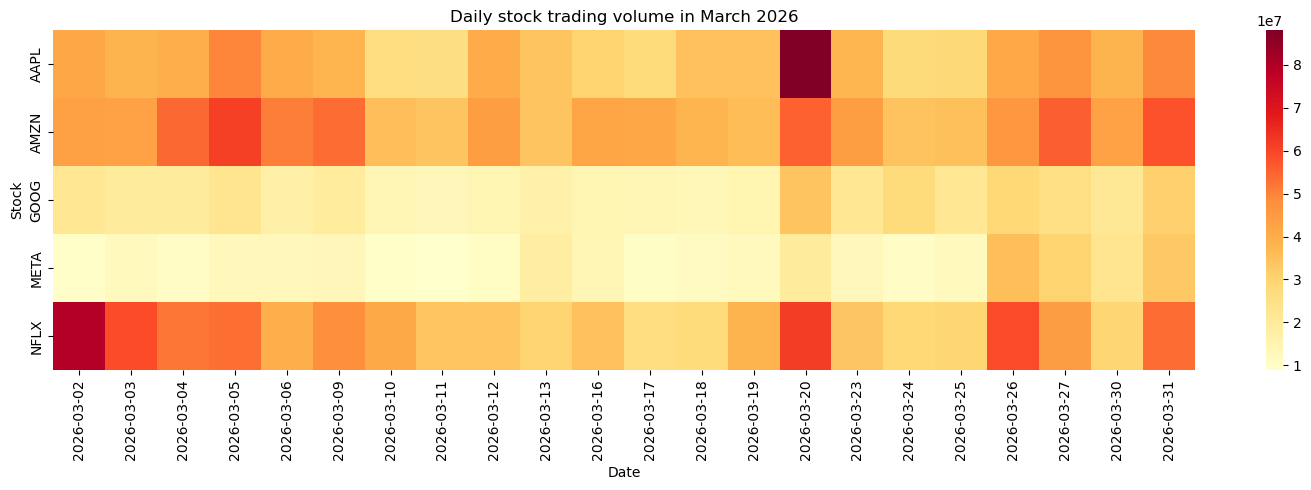

In [9]:
volume_pivot = df.pivot(index="symbol", columns="date", values="volume")

plt.figure(figsize=(15, 5))
sns.heatmap(volume_pivot, cmap="YlOrRd")
plt.title("Daily stock trading volume in March 2026")
plt.xlabel("Date")
plt.ylabel("Stock")
plt.tight_layout()
plt.show()

# Task 4: Exporting and importing data (1p)

### a) Export the JSON data retrieved in Task 2a as a JSON file stockdata.json into a subfolder called exports.

In [10]:
import json
os.makedirs("exports", exist_ok=True)
with open("exports/stockdata.json", "w") as f:
    json.dump(data, f)

### b) Export the DataFrame from Task 2b as a CSV file stockdata.csv into the same exports subfolder.

In [11]:
df.to_csv("exports/stockdata.csv", index=False)

### c) Print the first five rows of each and verify that the data looks identical to what it was in Task 2.

In [12]:
df_json = pd.DataFrame(json.load(open("exports/stockdata.json"))["data"])
df_csv = pd.read_csv("exports/stockdata.csv")

print("First 5 rows from JSON:")
display(df_json.head())

print("First 5 rows from CSV:")
display(df_csv.head())

First 5 rows from JSON:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31T00:00:00+0000
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31T00:00:00+0000
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31T00:00:00+0000
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31T00:00:00+0000
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31T00:00:00+0000


First 5 rows from CSV:


,open,high,low,close,volume,adj_high,adj_low,adj_close,adj_open,adj_volume,split_factor,dividend,symbol,exchange,date
0,247.890,255.48,247.101,253.79,48770963.0,255.48,247.101,253.79,247.910,49598091.0,1.0,0.0,AAPL,XNAS,2026-03-31
1,204.875,210.28,204.140,208.27,57843337.0,210.28,204.140,208.27,204.845,58470078.0,1.0,0.0,AMZN,XNAS,2026-03-31
2,277.840,287.05,276.810,286.86,30680107.0,287.05,276.760,286.86,277.540,31625057.0,1.0,0.0,GOOG,XNAS,2026-03-31
3,549.980,573.69,546.770,572.13,32809500.0,573.69,546.770,572.13,549.980,32898272.0,1.0,0.0,META,ARCX,2026-03-31
4,93.250,96.26,93.170,96.15,53674277.0,96.26,93.030,96.15,93.030,54269957.0,1.0,0.0,NFLX,XNAS,2026-03-31


# Task 5: Querying the Northwind database (1p)

In [13]:
import sqlite3
conn = sqlite3.connect("northwind.db")

### a) Connect to the database and list all tables it contains (print the table names).

In [14]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


### b) Write a SQL query that retrieves all products with a unit price above 30, showing ProductName, UnitPrice, and UnitsInStock. Load the result into a DataFrame and print it.

In [15]:
query_5b = """
    SELECT ProductName, UnitPrice, UnitsInStock
    FROM Products
    WHERE UnitPrice > 30
"""
df_5b = pd.read_sql_query(query_5b, conn)
display(df_5b)

,ProductName,UnitPrice,UnitsInStock
0,Northwoods Cranberry Sauce,40.00,6
1,Mishi Kobe Niku,97.00,29
2,Ikura,31.00,31
3,Queso Manchego La Pastora,38.00,86
4,Alice Mutton,39.00,0
5,Carnarvon Tigers,62.50,42
6,Sir Rodney's Marmalade,81.00,40
7,Gumbär Gummibärchen,31.23,15
8,Schoggi Schokolade,43.90,49
9,Rössle Sauerkraut,45.60,26


### c) Write a SQL query that joins the Orders, Customers, and Order Details tables to show CompanyName, OrderID, OrderDate, ShipCountry, and the line total (UnitPrice * Quantity) for all orders shipped to Germany. Load the result into a DataFrame and print it.

In [16]:
query_5c = """
    SELECT c.CompanyName,
           o.OrderID,
           o.OrderDate,
           o.ShipCountry,
           od.UnitPrice * od.Quantity AS LineTotal
    FROM Orders o
    JOIN Customers c ON o.CustomerID = c.CustomerID
    JOIN "Order Details" od ON o.OrderID = od.OrderID
    WHERE o.ShipCountry = "Germany"
"""
df_5c = pd.read_sql_query(query_5c, conn)
display(df_5c)

,CompanyName,OrderID,OrderDate,ShipCountry,LineTotal
0,Toms Spezialitäten,10249,2016-07-05,Germany,167.4
1,Toms Spezialitäten,10249,2016-07-05,Germany,1696.0
2,Ottilies Käseladen,10260,2016-07-19,Germany,123.2
3,Ottilies Käseladen,10260,2016-07-19,Germany,780.0
4,Ottilies Käseladen,10260,2016-07-19,Germany,591.0
...,...,...,...,...,...
80668,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,864.0
80669,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,735.0
80670,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,75.0
80671,Comércio Mineiro,26519,2022-08-26 16:17:42,Germany,500.0


# Task 6: Visualizing Northwind data (1p)

### a) Create a bar plot showing the number of orders per customer (for the top 10 customers who shipped to Germany).

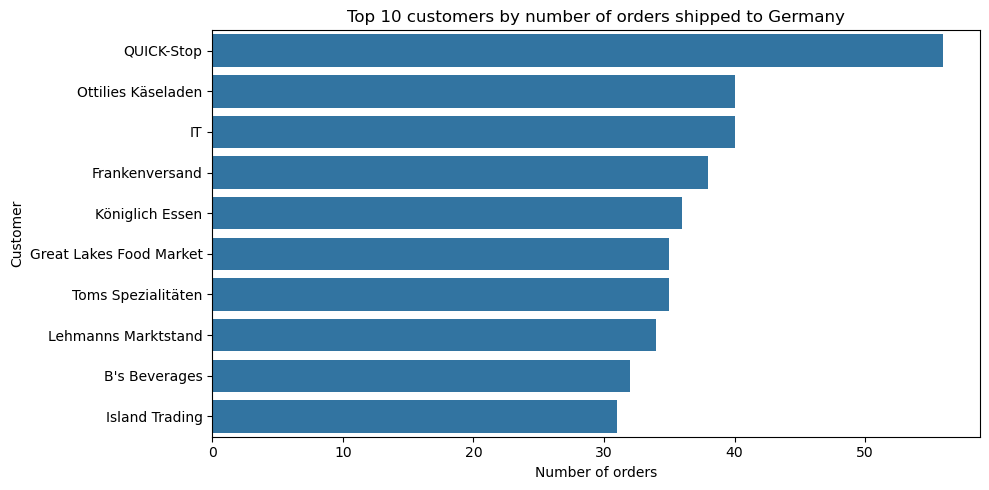

In [17]:
orders_per_customer = df_5c.groupby("CompanyName")["OrderID"].nunique()
orders_per_customer = orders_per_customer.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=orders_per_customer.values, y=orders_per_customer.index)
plt.title("Top 10 customers by number of orders shipped to Germany")
plt.xlabel("Number of orders")
plt.ylabel("Customer")
plt.tight_layout()
plt.show()

### b) Compute the total sales per order date and create a density plot (KDE plot) of daily total sales for orders shipped to Germany.

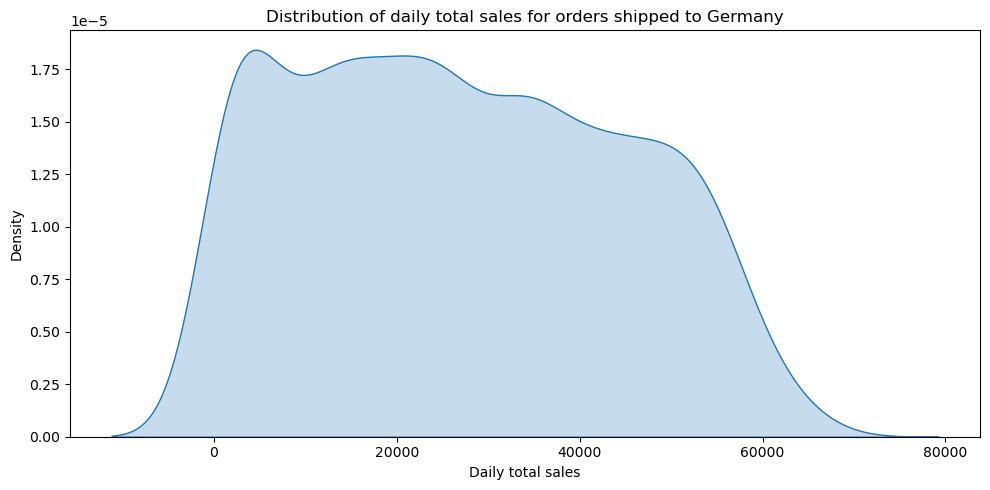

In [18]:
daily_sales = df_5c.groupby("OrderDate")["LineTotal"].sum()

plt.figure(figsize=(10, 5))
sns.kdeplot(daily_sales, fill=True)
plt.title("Distribution of daily total sales for orders shipped to Germany")
plt.xlabel("Daily total sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### c) Write a new SQL query that joins OrderDetails, Products, and Categories using inner joins to compute the total revenue (UnitPrice * Quantity) per product category. Load the result into a DataFrame and create a bar plot showing total revenue by category.

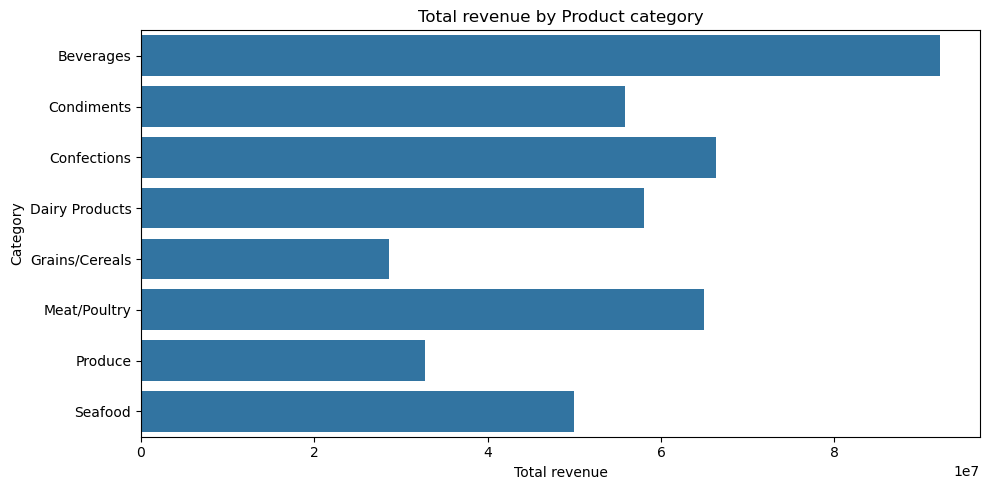

In [19]:
query_6c = """
    SELECT cat.CategoryName,
           SUM(od.UnitPrice * od.Quantity) AS TotalRevenue
    FROM "Order Details" od
    JOIN Products p ON od.ProductID = p.ProductID
    JOIN Categories cat ON p.CategoryID = cat.CategoryID
    GROUP BY cat.CategoryName
"""
df_6c = pd.read_sql_query(query_6c, conn)

plt.figure(figsize=(10, 5))
sns.barplot(data=df_6c, x="TotalRevenue", y="CategoryName")
plt.title("Total revenue by Product category")
plt.xlabel("Total revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Task 7: Comparing Python to SQL (1p)

### a) Write a SQL query that retrieves the full Products table and the full Categories table into separate DataFrames. Print the first 5 rows of each.

In [20]:
df_products = pd.read_sql_query("SELECT * FROM Products", conn)
df_categories = pd.read_sql_query("SELECT * FROM Categories", conn)

print("Products table first 5 rows:")
display(df_products.head())

print("Categories table first 5 rows:")
display(df_categories.head())

Products table first 5 rows:


,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1


Categories table first 5 rows:


,CategoryID,CategoryName,Description,Picture
0,1,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Confections,"Desserts, candies, and sweet breads",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Dairy Products,Cheeses,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Grains/Cereals,"Breads, crackers, pasta, and cereal",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### b) Using pandas, perform an inner join on the two DataFrames from 7a on CategoryID.

In [21]:
df_joined = pd.merge(df_products, df_categories, on="CategoryID", how="inner")
display(df_joined.head())

,ProductID,ProductName,SupplierID,CategoryID,QuantityPerUnit,UnitPrice,UnitsInStock,UnitsOnOrder,ReorderLevel,Discontinued,CategoryName,Description,Picture
0,1,Chai,1,1,10 boxes x 20 bags,18.00,39,0,10,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
1,2,Chang,1,1,24 - 12 oz bottles,19.00,17,40,25,0,Beverages,"Soft drinks, coffees, teas, beers, and ales",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
2,3,Aniseed Syrup,1,2,12 - 550 ml bottles,10.00,13,70,25,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
3,4,Chef Anton's Cajun Seasoning,2,2,48 - 6 oz jars,22.00,53,0,0,0,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...
4,5,Chef Anton's Gumbo Mix,2,2,36 boxes,21.35,0,0,0,1,Condiments,"Sweet and savory sauces, relishes, spreads, an...",b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x02\x00...


### c) Replicate with Python the SQL code of Task 6c, retrieving first the tables fully using SQL and joining them with pandas. Using %%time or time.time(), compare the execution speed of performing the join fully with SQL (as in 6c) versus performing it in Python with pandas after retrieving via SQL the tables only (similar to what was done in Task 7a-b). Print both execution times and briefly comment on which was faster.

In [22]:
import time

# SQL version
start_sql = time.time()
sql_result = pd.read_sql_query(query_6c, conn)
end_sql = time.time()
sql_time = end_sql - start_sql

# Python version
start_py = time.time()
order_details = pd.read_sql_query("SELECT * FROM 'Order Details'", conn)
products = pd.read_sql_query("SELECT * FROM Products", conn)
categories = pd.read_sql_query("SELECT * FROM Categories", conn)

merged_py = order_details.merge(products, on="ProductID").merge(categories, on="CategoryID")
merged_py["Revenue"] = merged_py["UnitPrice_x"] * merged_py["Quantity"]
merged_py.groupby("CategoryName")["Revenue"].sum()
end_py = time.time()
py_time = end_py - start_py

print(f"SQL execution time:    {sql_time:.4f} seconds")
print(f"Pandas execution time: {py_time:.4f} seconds")
if sql_time < py_time:
    print("SQL was faster")
else:
    print("Pandas was faster")

SQL execution time:    0.7935 seconds
Pandas execution time: 1.5338 seconds
SQL was faster


# Task 8: Wide and long format (1p)

In [23]:
wide_data = pd.DataFrame({
    "store": ["Helsinki", "Tampere", "Turku"],
    "Q1_sales": [12000, 8500, 9200],
    "Q2_sales": [13500, 9100, 9800],
    "Q3_sales": [11800, 8800, 10100],
    "Q4_sales": [15000, 10200, 11500]
})

long_data = pd.DataFrame({
    "month": ["Jan", "Jan", "Feb", "Feb", "Mar", "Mar"],
    "product": ["Laptop", "Phone", "Laptop", "Phone", "Laptop", "Phone"],
    "units_sold": [45, 120, 50, 110, 55, 130]
})

### a) Convert wide_data from wide to long format using pd.melt(). Print the DataFrame before and after conversion.

In [24]:
print("wide_data before:")
display(wide_data)

wide_to_long = pd.melt(wide_data, id_vars="store", var_name="quarter", value_name="sales")
print("wide_data after melt:")
display(wide_to_long)

wide_data before:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


wide_data after melt:


,store,quarter,sales
0,Helsinki,Q1_sales,12000
1,Tampere,Q1_sales,8500
2,Turku,Q1_sales,9200
3,Helsinki,Q2_sales,13500
4,Tampere,Q2_sales,9100
5,Turku,Q2_sales,9800
6,Helsinki,Q3_sales,11800
7,Tampere,Q3_sales,8800
8,Turku,Q3_sales,10100
9,Helsinki,Q4_sales,15000


### b) Convert long_data from long to wide format using .pivot(). Print the DataFrame before and after conversion.

In [25]:
print("long_data before:")
display(long_data)

long_to_wide = long_data.pivot(index="month", columns="product", values="units_sold")
print("long_data after pivot:")
display(long_to_wide)

long_data before:


,month,product,units_sold
0,Jan,Laptop,45
1,Jan,Phone,120
2,Feb,Laptop,50
3,Feb,Phone,110
4,Mar,Laptop,55
5,Mar,Phone,130


long_data after pivot:


product,Laptop,Phone
month,,
Feb,50,110
Jan,45,120
Mar,55,130


### c) Convert both transformed datasets back to their original format. Print the datasets before and after to confirm they match the originals.

In [26]:
# Long back to wide
back_to_wide = wide_to_long.pivot(index="store", columns="quarter", values="sales").reset_index()
back_to_wide.columns.name = None
print("Converted back to wide:")
display(back_to_wide)

# Wide back to long
back_to_long = long_to_wide.reset_index().melt(id_vars="month", value_name="units_sold")
back_to_long = back_to_long.sort_values(["month", "product"]).reset_index(drop=True)
print("Converted back to long:")
display(back_to_long)

Converted back to wide:


,store,Q1_sales,Q2_sales,Q3_sales,Q4_sales
0,Helsinki,12000,13500,11800,15000
1,Tampere,8500,9100,8800,10200
2,Turku,9200,9800,10100,11500


Converted back to long:


,month,product,units_sold
0,Feb,Laptop,50
1,Feb,Phone,110
2,Jan,Laptop,45
3,Jan,Phone,120
4,Mar,Laptop,55
5,Mar,Phone,130


# Statement of use of AI

### Claude was used throughout this assignment to help with setting up the API requests, and debugging errors. All AI-generated code was reviewed and tested to ensure correctness